<a href="https://colab.research.google.com/github/chaeee01/3DGS-Character-Generation-Pipeline/blob/feature%2Fsam2-preprocess/SAM2_try3_260706.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##구글 드라이브 연결 및 SAM2 패키지 설치

In [ ]:
# 구글 드라이브와 코랩 컴퓨터를 연결하는 코드
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e .

Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 15.30 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/sam2
Obtaining file:///content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 17.3 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=13850 sha256=70be99db6b1a0054e06732559dd355ad91550354

## 프레임 쪼개기

In [ ]:
import os
import cv2
import torch
from sam2.build_sam import build_sam2_video_predictor

# 1. ⚠️ 구글 드라이브에 올려둔 영상 경로 (방금 복사한 경로를 붙여넣으세요)
video_path = "/content/drive/MyDrive/zombie_project/zombie_sample1.mp4"

# 2. 쪼개진 프레임들이 저장될 경로 (이것도 구글 드라이브로 지정하면 영구 저장됩니다!)
output_dir = "/content/drive/MyDrive/zombie_project/zombie_frames1"
os.makedirs(output_dir, exist_ok=True)

# 영상 읽기 및 프레임 쪼개기 작업 시작
cam = cv2.VideoCapture(video_path)
frame_idx = 0
while True:
    ret, frame = cam.read()
    if not ret:
        break
    # 파일명을 00000.jpg 형태로 저장
    cv2.imwrite(os.path.join(output_dir, f"{frame_idx:05d}.jpg"), frame)
    frame_idx += 1
cam.release()
print(f"총 {frame_idx}개의 좀비 비디오 프레임 추출 및 구글 드라이브 저장 완료!")

# 3. SAM 2 가중치 파일 다운로드 및 세팅
sam2_checkpoint = "./checkpoints/sam2_hiera_tiny.pt"
model_cfg = "sam2_hiera_t.yaml"

!mkdir -p checkpoints
!wget -P checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint)

총 69개의 좀비 비디오 프레임 추출 및 구글 드라이브 저장 완료!
--2026-07-06 02:23:17--  https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_tiny.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.62, 65.9.168.4, 65.9.168.52, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 155906050 (149M) [application/vnd.snesdev-page-table]
Saving to: ‘checkpoints/sam2_hiera_tiny.pt’

sam2_hiera_tiny.pt  100%[===================>] 148.68M   178MB/s    in 0.8s    

2026-07-06 02:23:18 (178 MB/s) - ‘checkpoints/sam2_hiera_tiny.pt’ saved [155906050/155906050]



try3는 '프레임 쪼개기'까지

try4는 쪼갠 프레임에서 좀비 타겟팅~배경 제거 객체 png파일로 받고 영상 생성

1단계: 동영상 상태 초기화하기

In [ ]:
# SAM 2 예측기 상태 초기화
inference_state = predictor.init_state(video_path=output_dir)

frame loading (JPEG): 100%|██████████| 69/69 [00:02<00:00, 27.09it/s]


2단계: 첫 번째 프레임(0번)에서 좀비 위치 알려주기 (프롬프트 지정)

In [ ]:
import numpy as np

ann_frame_idx = 0  # 첫 번째 프레임
ann_obj_id = 1     # 우리가 추적할 좀비 오브젝트의 ID (1번)

# 좀비가 있을 법한 위치의 좌표 [X, Y] 지정 (픽셀 기준)
# 예: 가로 500픽셀, 세로 500픽셀 위치에 좀비가 있다고 가정
'''
좌표 중앙값 수정함. 640,360
'''
points = np.array([[640, 360]], dtype=np.float32)

# 1은 '이 위치에 객체가 있다(Positive)', 0은 '배경이다(Negative)'를 의미
labels = np.array([1], dtype=np.int32)

# 첫 프레임에 프롬프트(점) 추가
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)
print("0번 프레임에 좀비 타겟 좌표 지정 완료!")

0번 프레임에 좀비 타겟 좌표 지정 완료!


### 대안 A: 점 2개 동시에 찍기 (멀티 포인트)

In [ ]:
import numpy as np

ann_frame_idx = 0
ann_obj_id = 1

# 1. 🎯 좀비 영역에 점 2개 지정 (가슴 중앙과 약간 위쪽 상체)
points = np.array([
    [640, 360],  # 첫 번째 점 (가슴)
    [640, 250]   # 두 번째 점 (상체/얼굴 부근 - 아까 격자 눈금 보고 조절 가능)
], dtype=np.float32)

# 2. 두 점 모두 좀비 객체 내부이므로 둘 다 1 (Positive)로 지정
labels = np.array([1, 1], dtype=np.int32)

# 첫 프레임에 멀티 프롬프트 추가
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)
print("🎯 점 2개로 좀비 타겟팅 완벽 조준!")

🎯 점 2개로 좀비 타겟팅 완벽 조준!


대안 B: 사각형 박스로 통째로 가두기 (바운딩 박스 - 가장 강력 추천)

In [ ]:
import numpy as np

ann_frame_idx = 0
ann_obj_id = 1

# 1. 📦 좀비를 감싸는 사각형 박스 좌표 지정 [시작X, 시작Y, 끝X, 끝Y]
# 아까 격자 눈금을 보고 좀비 몸 전체가 들어가는 네모 박스 범위를 적어줍니다.
box = np.array([500, 150, 800, 650], dtype=np.float32)

# 박스를 인풋으로 주어 타겟팅 추가
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    box=box,
)
print("🎯 바운딩 박스로 좀비 몸 전체 타겟팅 완료!")

🎯 바운딩 박스로 좀비 몸 전체 타겟팅 완료!


3단계: 전체 프레임으로 마스크 전성(Propagate)하기

In [ ]:
# 전체 비디오에서 좀비 추적 및 마스크 생성 (가장 핵심적인 AI 추론 루프)
video_segments = {}
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }
print("전체 프레임에 대한 좀비 추적 및 마스크 생성 완료!")

propagate in video: 100%|██████████| 69/69 [00:10<00:00,  6.30it/s]

전체 프레임에 대한 좀비 추적 및 마스크 생성 완료!


지금 실행한 코드까지가 AI가 메모리 상에 "몇 번 프레임의 어느 픽셀이 좀비 영역이다"라는 데이터(video_segments)를 마스터한 상태

"배경은 투명(알파 채널)하게 날려버리고 좀비 객체만 쏙 빠진 최종 PNG 이미지 시퀀스"를 구글 드라이브에 파일로 뽑아낼 차례

### 배경을 투명하게 날린 좀비 PNG 에셋 실시간 저장
이 코드는 AI가 계산해 둔 video_segments 마스크 정보를 바탕으로, 원본 프레임 이미지에서 좀비 픽셀만 뜯어내어 배경이 투명한 4채널(BGRA) PNG 파일로 구글 드라이브에 저장

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# 1. 누끼 완료된 PNG 파일들이 저장될 구글 드라이브 새 폴더 생성
save_dir = "/content/drive/MyDrive/zombie_project/zombie_output2_pngs"
os.makedirs(save_dir, exist_ok=True)

# 2. 아까 쪼개두었던 원본 JPG 프레임 경로 및 파일 목록 정렬
frames_dir = "/content/drive/MyDrive/zombie_project/zombie_frames1"
frame_names = sorted([f for f in os.listdir(frames_dir) if f.endswith(".jpg")])

print("🎬 좀비 객체 분리 및 투명 배경 PNG 변환 작업을 시작합니다...")

# 3. 전체 프레임을 돌며 마스크 적용 후 저장 (tqdm으로 진척도 시각화)
for frame_idx, frame_name in enumerate(tqdm(frame_names)):
    # 원본 이미지 로드 (BGR 3채널)
    img_path = os.path.join(frames_dir, frame_name)
    src_img = cv2.imread(img_path)

    if src_img is None:
        continue

    h, w, _ = src_img.shape

    # 완전히 투명한 도화지 생성 (Blue, Green, Red, Alpha) -> 알파 0은 완전 투명
    rgba_output = np.zeros((h, w, 4), dtype=np.uint8)

    # 해당 프레임에 AI가 찾은 마스크가 존재하는지 확인
    if frame_idx in video_segments and 1 in video_segments[frame_idx]:
        # 좀비 마스크 추출 (True / False 행렬)
        zombie_mask = video_segments[frame_idx][1].squeeze()

        # 좀비 영역(True)에 해당하는 픽셀만 원본에서 BGR 복사
        rgba_output[zombie_mask, 0:3] = src_img[zombie_mask, 0:3]
        # 좀비 영역의 알파 채널(불투명도)을 255(완전 불투명)로 설정
        rgba_output[zombie_mask, 3] = 255
    else:
        # 만약 AI가 해당 프레임에서 놓쳤다면 안전장치로 전틀(전체 투명) 처리하거나 원본 유지
        pass

    # 구글 드라이브에 투명 PNG 파일로 최종 저장 (파일명 예: zombie_00000.png)
    out_filename = f"zombie_{frame_idx:05d}.png"
    cv2.imwrite(os.path.join(save_dir, out_filename), rgba_output)

print(f"\n🎯 [대성공] 전 처리 완료! 총 {len(frame_names)}장의 좀비 에셋이 '{save_dir}'에 투명 PNG로 저장되었습니다.")

🎬 좀비 객체 분리 및 투명 배경 PNG 변환 작업을 시작합니다...


100%|██████████| 69/69 [00:02<00:00, 31.08it/s]


🎯 [대성공] 전 처리 완료! 총 69장의 좀비 에셋이 '/content/drive/MyDrive/zombie_project/zombie_output2_pngs'에 투명 PNG로 저장되었습니다.


1차 결과:좀비도 아닌 배경 일부 마스킹 됨. 배경은 격자무늬로 제거됨

-> 좀비 객체 제대로 인식 안 됨.

In [ ]:
import cv2

# 원본 영상 경로 (채연 님이 3번 셀에 넣었던 원본 영상 경로를 적어주세요)
video_path = "/content/drive/MyDrive/zombie_project/zombie_sample1.mp4"

cam = cv2.VideoCapture(video_path)
width = int(cam.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cam.get(cv2.CAP_PROP_FRAME_HEIGHT))
cam.release()

print(f"📐 채연 님 영상의 실제 해상도: 가로 {width}px × 세로 {height}px")
print(f"🎯 정확한 정중앙 좌표는 딱 이 숫자입니다 ➡️ [ {int(width/2)}, {int(height/2)} ]")

📐 채연 님 영상의 실제 해상도: 가로 1280px × 세로 720px
🎯 정확한 정중앙 좌표는 딱 이 숫자입니다 ➡️ [ 640, 360 ]


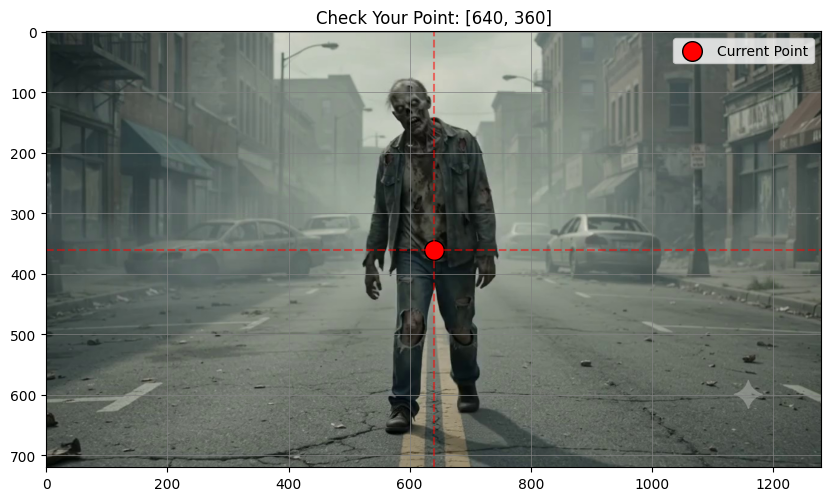

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. 0번 원본 프레임 이미지 읽기
frame_path = "/content/drive/MyDrive/zombie_project/zombie_frames1/00000.jpg"
img = cv2.imread(frame_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. 지금 설정된 테스트 좌표 [X, Y]
test_x, test_y = 640, 360

# 3. 이미지 위에 빨간색 큰 점과 격자 그리기
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axvline(x=test_x, color='r', linestyle='--', alpha=0.5)
plt.axhline(y=test_y, color='r', linestyle='--', alpha=0.5)
plt.scatter([test_x], [test_y], color='red', s=200, edgecolors='black', label='Current Point')
plt.grid(True, which='both', color='gray', linestyle='-', linewidth=0.5)
plt.title(f"Check Your Point: [{test_x}, {test_y}]")
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

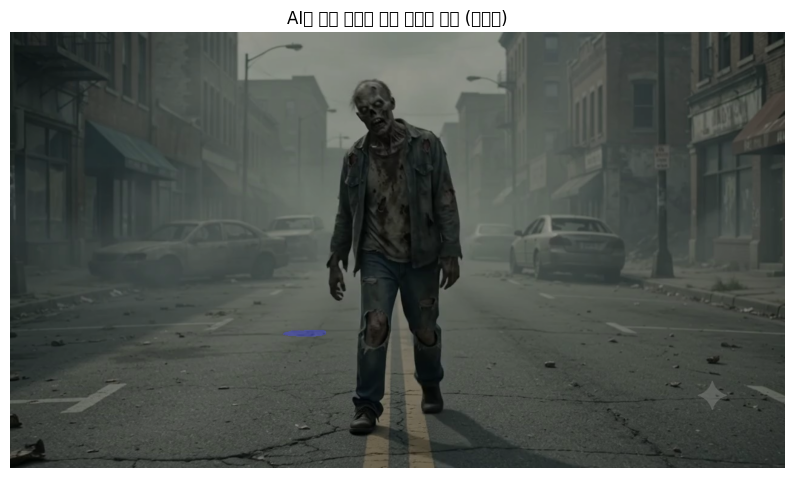

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. 0번 프레임의 마스크 데이터 가져오기 (1번 객체)
# video_segments는 채연 님이 5번 셀(propagate_in_video) 돌릴 때 저장된 메모리입니다.
if 0 in video_segments and 1 in video_segments[0]:
    zombie_mask = video_segments[0][1].squeeze()

    # 2. 원본 0번 프레임 읽기
    frame_path = "/content/drive/MyDrive/zombie_project/zombie_frames1/00000.jpg"
    img = cv2.imread(frame_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 3. 마스크 영역을 푸른색 반투명 레이어로 합성
    mask_visual = np.zeros_like(img_rgb)
    mask_visual[zombie_mask] = [0, 0, 255] # 빨간색/파란색 채우기

    blended = cv2.addWeighted(img_rgb, 0.7, mask_visual, 0.3, 0)

    plt.figure(figsize=(10, 6))
    plt.imshow(blended)
    plt.title("AI가 현재 인식한 실제 마스크 영역 (빨간색)")
    plt.axis('off')
    plt.show()
else:
    print("❌ 0번 프레임에 대한 마스크 메모리가 존재하지 않습니다. 4, 5번 셀을 다시 확인해 주세요.")

## SAM2 최종 260706

가로 세로 픽셀 크기 고려 안 하고..(500,500) 좌표 넣었을 때 -> 좀비 객체 자체 조준 못 함 => 객체가 아닌 엉뚱한 배경 마스킹 됨
* 픽셀 (640,360)으로 수정 후, try1 코드에서 다시 실행
* jupyter 캐시 오류남 -> 쪼개진 프레임으로 try2에서 다시 실행 => 성공